# Irreversible sampling on Titanic and MAGIC

Accuracy **and** log-loss from a cold `w = 0` start, for three skew-symmetric fields:

| field | drift |
|---|---|
| `J = 0` | reversible baseline, $-D\,\hat g$ |
| constant $J_a$ | $-(D + J_a)\hat g$, with $J_a$ designed from the warm-up Hessian |
| state-dependent $J_s$ | the same design behind a gate on the posterior bulk, plus its divergence correction |

**The target.** Bayesian logistic regression. The potential is the logistic negative
log-likelihood plus a Gaussian (ridge) prior and nothing else,

$$U(w) \;=\; \sum_i \Big[\log\big(1 + e^{x_i \cdot w}\big) - y_i\,(x_i \cdot w)\Big] \;+\; \tfrac{1}{2}\sum_j \frac{w_j^2}{\sigma_j^2},
\qquad \sigma_j = 2,\quad \sigma_0 = 10,$$

so the regularizer is $\tfrac{\lambda}{2}\lVert w\rVert^2$ with $\lambda = 0.25$ on every
coefficient and $0.01$ on the intercept. Features are standardised on the training split.

**The sampler never differentiates $U$.** The drift uses a central-difference surrogate
$\hat g_j(w) = [U(w + \epsilon e_j) - U(w - \epsilon e_j)]/2\epsilon$, and the divergence
correction $\Gamma = \nabla\!\cdot\!J$ is closed form because $J$ is chosen, not derived from
the target. The dynamics are run **unadjusted**: a Metropolis step enforces detailed balance,
which would reversibilise the chain and throw away exactly what $J$ is for.

**Two metrics, both on the held-out 30%**, from the running posterior predictive
$\bar p_t = \tfrac{1}{t+1}\sum_{s \le t} \sigma(X_\text{test} w_s)$:

* accuracy, thresholded at one half (ties count one half, so the $w = 0$ start scores 0.5);
* log-loss in nats, which reads the whole probability rather than which side of one half it
  falls on, and so responds to the posterior spread.

Both are compared against a gold-standard reference posterior (long gradient-based MALA).
Runtime is about ten minutes, mostly MAGIC's warm-up; the settings in
`experiments/run_designed.py` are heavier and produce the figures in the README.

In [1]:
import json, os, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))

from nds.data import PRETTY_NAMES, load
from nds.design import calibrate_amplitude, explicit_step_size, paired_skew
from nds.metrics import iterations_to_reach
from nds.reference import reference_posterior
from nds.sampler import Geometry, run_chain, stable_step_size, warm_up
from nds.skew import ConstantSkew, GatedSkew, ZeroSkew
from nds.target import LogisticPosterior

DATASETS = ["titanic", "magic"]
N_ITER = 200          # iterations per chain, from w = 0
N_WALKERS = 24        # independent walkers, averaged in the figures
SAFETY = 0.15         # step size is 2 * SAFETY / max Re mu
AMPLITUDES = (0.0, 0.2, 0.5, 1.0)   # rotation amplitudes the calibration tries
GATE_FRACTION, GATE_WIDTH = 0.75, 0.1
WARMUP = dict(n_iter=200, n_walkers=8, n_rounds=2, shrinkage=0.05)
SEED = 0
RESULTS = os.path.abspath(os.path.join("..", "results"))

np.set_printoptions(precision=4, suppress=True)
print("numpy", np.__version__)

numpy 2.4.6


## 1. The two datasets

Titanic is small and nearly isotropic; MAGIC has fifty times the data and a posterior whose
condition number is an order of magnitude worse, which is where an irreversible perturbation
has something to fix.

In [2]:
data = {name: load(name, seed=0) for name in DATASETS}
targets = {name: LogisticPosterior(ds.X_train, ds.y_train, prior_scale=2.0) for name, ds in data.items()}

pd.DataFrame([
    {
        "dataset": PRETTY_NAMES[name],
        "d": ds.dim,
        "n_train": len(ds.y_train),
        "n_test": len(ds.y_test),
        "positives (train)": round(float(ds.y_train.mean()), 3),
        "U(0)": round(float(targets[name].potential(np.zeros((ds.dim, 1)))[0]), 1),
    }
    for name, ds in data.items()
])

,dataset,d,n_train,n_test,positives (train),U(0)
0,Titanic (survival),10,623,268,0.384,431.8
1,MAGIC Gamma Telescope,11,13314,5706,0.648,9228.6


## 2. Reference posterior

The dashed lines in every figure below. This run *does* use analytic gradients and a Laplace
preconditioner: the reference has to be more trustworthy than the methods it judges. Its two
halves agree to four decimals. Cached files from the repository are reused when present.

In [3]:
def get_reference(name, ds, target):
    path = os.path.join(RESULTS, f"reference_{name}.npz")
    if os.path.exists(path):
        blob = np.load(path)
        return {k: blob[k] for k in blob.files}
    ref = reference_posterior(target, ds.X_test, ds.y_test, n_iter=20000, n_chains=8, seed=SEED)
    return ref


def log_loss(p, y, eps=1e-12):
    q = np.clip(p, eps, 1 - eps)
    return float(-(y * np.log(q) + (1 - y) * np.log1p(-q)).mean())


references = {}
for name, ds in data.items():
    ref = get_reference(name, ds, targets[name])
    references[name] = {
        "accuracy": float(ref["accuracy"]),
        "loss": log_loss(ref["predictive"], ds.y_test),
        "mean": ref["posterior_mean"],
        "cov": ref["posterior_cov"],
    }

pd.DataFrame([
    {"dataset": PRETTY_NAMES[n], "reference accuracy": round(r["accuracy"], 4),
     "reference log-loss": round(r["loss"], 4)}
    for n, r in references.items()
])

,dataset,reference accuracy,reference log-loss
0,Titanic (survival),0.7836,0.4553
1,MAGIC Gamma Telescope,0.7948,0.4586


## 3. Warm-up and the design

Two `J = 0` pilot rounds estimate the posterior covariance $\hat\Sigma$ and mean $\hat m$; nothing
here uses a gradient or the held-out labels. Writing $\hat H = \hat\Sigma^{-1}$:

* `paired_skew` works in the eigenbasis of $\hat H$ and couples the $k$-th slowest direction to
  the $k$-th fastest. In a block with rates $a < b$ the coupling $s$ makes both rates real and
  equal to the block mean $(a+b)/2$ at $s = (b-a)/(2\sqrt{ab})$, the *collision* amplitude.
  Pairing slowest with fastest maximises the smallest block mean, which is the most a skew term
  can do: $\operatorname{tr}\big((D+J)\hat H\big)$ does not depend on $J$, so rate bought for the
  slow directions is sold from the fast ones.
* The amplitude is calibrated by a short pilot, scored by how fast the ensemble reaches the
  target spread along the slowest directions. `0.0` is in the ladder, so the procedure may
  conclude that no rotation is better than some.
* Each field then gets its own step size from $h = 2\,\text{safety}/\max \operatorname{Re}\mu$.
  That is the classical explicit optimum for the reversible chain, and it fixes the worst-case
  variance inflation of the unadjusted chain at $2/(2 - 2\,\text{safety}) = 1.18$, so the fields
  are compared at matched discretisation bias even though each runs at its own step.
* The state-dependent field is the same rotation behind a gate,
  $s(w) = \big[1 + e^{(r(w) - R)/W}\big]^{-1}$ with $r(w)^2 = (w-\hat m)^\top \hat H (w-\hat m)$:
  outside the gate the chain is reversible, inside it the full design applies. That is what lets
  it keep the collision amplitude on a posterior the constant field cannot take it on.

In [4]:
designs = {}
for name, ds in data.items():
    t0 = time.time()
    target = targets[name]
    pilot = warm_up(target, seed=SEED, **WARMUP)
    geo_pre, m_hat = pilot["geometry"], pilot["mean_state"]
    H_hat = geo_pre.D_inv
    r0 = float(np.sqrt(max(m_hat @ (H_hat @ m_hat), 1e-12)))
    identity = Geometry.identity(target.d)

    def make_constant(amplitude, H=H_hat):
        J, _ = paired_skew(H, amplitude=amplitude)
        return ConstantSkew(J, 1.0), J

    def make_gated(amplitude, drop=False, H=H_hat, m=m_hat, radius=r0):
        J, _ = paired_skew(H, amplitude=amplitude)
        field = GatedSkew(J, 1.0, radius=GATE_FRACTION * radius, width=GATE_WIDTH * radius,
                          metric=H, center=m, drop_correction=drop)
        return field, J

    amps = {}
    for key, factory in (("constant", make_constant), ("state", make_gated)):
        cal = calibrate_amplitude(target, H_hat, m_hat, make_field=factory,
                                  amplitudes=AMPLITUDES, safety=SAFETY,
                                  n_iter=200, n_walkers=16, seed=SEED, guard_iter=100)
        amps[key] = cal

    a_const, a_state = amps["constant"]["amplitude"], amps["state"]["amplitude"]
    J_const, report_const = paired_skew(H_hat, amplitude=a_const)
    J_state, report_state = paired_skew(H_hat, amplitude=a_state)

    designs[name] = {
        "geometry": identity,
        "precond": geo_pre,
        "H": H_hat,
        "mean": m_hat,
        "r0": r0,
        "amplitudes": {"constant": a_const, "state": a_state},
        "ladders": {k: v["ladder"] for k, v in amps.items()},
        "reports": {"constant": report_const, "state": report_state},
        "fields": {
            "zero": ZeroSkew(),
            "constant": make_constant(a_const)[0],
            "state": make_gated(a_state)[0],
        },
        "steps": {
            "zero": explicit_step_size(H_hat, None, safety=SAFETY),
            "constant": explicit_step_size(H_hat, J_const, safety=SAFETY),
            "state": explicit_step_size(H_hat, J_state, safety=SAFETY),
        },
        "seconds": time.time() - t0,
    }
    print(f"{name}: warm-up and calibration in {designs[name]['seconds']:.0f}s, "
          f"amplitudes {designs[name]['amplitudes']}")

titanic: warm-up and calibration in 14s, amplitudes {'constant': 1.0, 'state': 1.0}


magic: warm-up and calibration in 322s, amplitudes {'constant': 1.0, 'state': 1.0}


In [5]:
rows = []
for name, dz in designs.items():
    rep = dz["reports"]["state"]
    rows.append({
        "dataset": PRETTY_NAMES[name],
        "cond(H)": round(rep["condition_number"], 1),
        "slowest rate, J = 0": round(rep["reversible_rate"], 4),
        "slowest rate, designed": round(rep["irreversible_rate"], 4),
        "best possible (mean rate)": round(rep["mean_rate_bound"], 4),
        "amplitude, constant": dz["amplitudes"]["constant"],
        "amplitude, gated": dz["amplitudes"]["state"],
        "h, J = 0": f"{dz['steps']['zero']:.3g}",
        "h, gated / h, J = 0": round(dz["steps"]["state"] / dz["steps"]["zero"], 2),
    })
pd.DataFrame(rows).set_index("dataset").T

dataset,Titanic (survival),MAGIC Gamma Telescope
cond(H),12.4,69.2
"slowest rate, J = 0",11.0575,46.4748
"slowest rate, designed",67.5028,988.7651
best possible (mean rate),72.5491,1174.9497
"amplitude, constant",1.0,1.0
"amplitude, gated",1.0,1.0
"h, J = 0",0.0022,9.33e-05
"h, gated / h, J = 0",1.76,1.97


## 4. Run the three fields

Same walker seeds for every field, so the curves differ only by the drift. The stability guard
halves the step size if a short pilot shows the unadjusted chain failing to settle; it records
when it fires.

In [6]:
runs = {}
for name, ds in data.items():
    dz = designs[name]
    target = targets[name]
    ref_metric = np.linalg.pinv(references[name]["cov"])
    runs[name] = {}
    for key, field in dz["fields"].items():
        h = stable_step_size(target, field, dz["steps"][key], n_iter=100, n_walkers=8,
                             seed=SEED + 5, geometry=dz["geometry"])["step_size"]
        res = run_chain(target, field, h, N_ITER, n_walkers=N_WALKERS, seed=SEED + 101,
                        X_eval=ds.X_test, y_eval=ds.y_test, geometry=dz["geometry"],
                        metropolis=False, ref_mean=references[name]["mean"],
                        ref_metric=ref_metric)
        runs[name][key] = {
            "step_size": h,
            "accuracy": res.accuracy.mean(axis=1),
            "loss": res.loss.mean(axis=1),
            "error": res.mean_error.mean(axis=1),
        }
        print(f"{name:8s} {key:9s} h={h:.4g}  accuracy {res.accuracy[-1].mean():.4f}  "
              f"log-loss {res.loss[-1].mean():.4f}")

titanic  zero      h=0.002197  accuracy 0.7825  log-loss 0.4566


titanic  constant  h=0.003862  accuracy 0.7828  log-loss 0.4555


titanic  state     h=0.003862  accuracy 0.7826  log-loss 0.4555


magic    zero      h=9.326e-05  accuracy 0.7937  log-loss 0.4587


magic    constant  h=0.0001839  accuracy 0.7946  log-loss 0.4586


magic    state     h=0.0001839  accuracy 0.7945  log-loss 0.4585


## 5. Accuracy and loss

Left column accuracy, right column log-loss, one row per dataset, three fields each. The dashed
line is the reference posterior's own value on the same test set and the grey band is a
tolerance around it: for accuracy `+/- 0.005`, for loss `+/- 1%`. The y-axes skip the first two
iterations, where every curve leaves the `w = 0` values 0.5 and `log 2`.

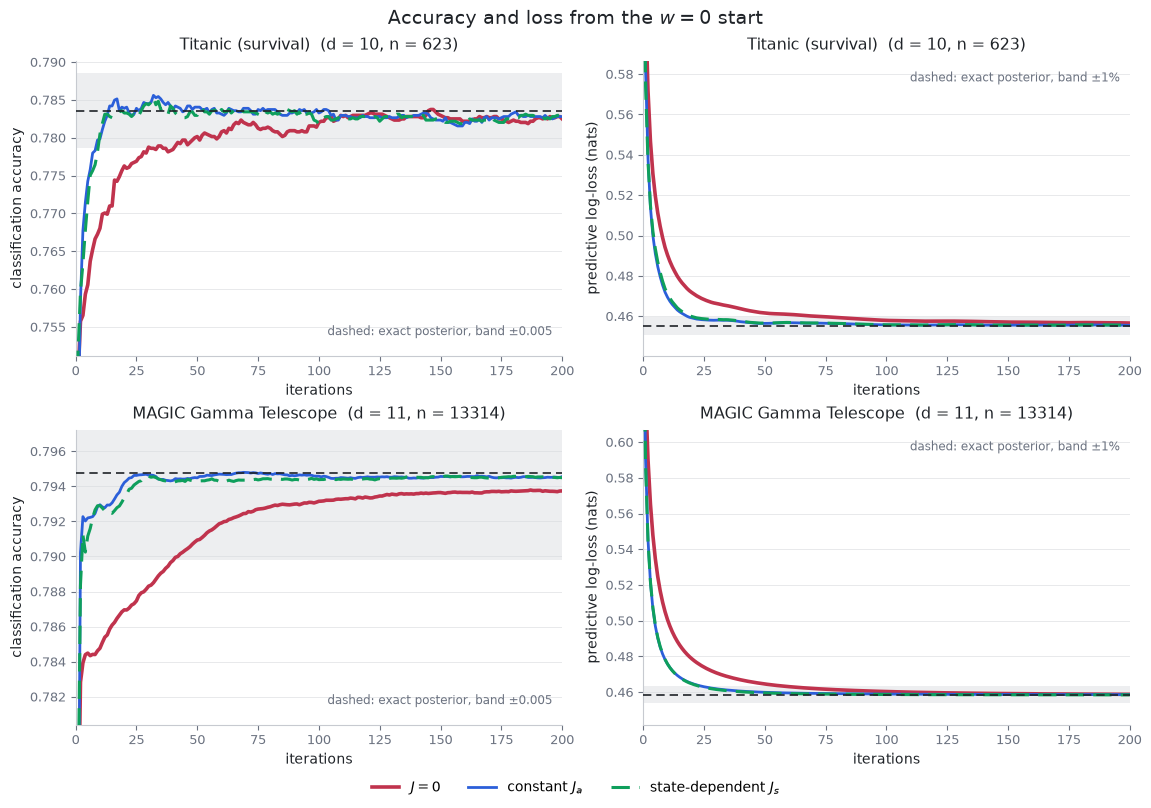

In [7]:
PALETTE = {
    "zero": ("#C0334D", "-", 2.6, r"$J = 0$"),
    "constant": ("#2B5FD9", "-", 2.0, r"constant $J_a$"),
    "state": ("#0E9F5C", (0, (6, 3)), 2.2, r"state-dependent $J_s$"),
}
INK, MUTED = "#1f2328", "#6b7280"


def style_axes(ax):
    ax.grid(True, axis="y", color="#d8dade", lw=0.6, alpha=0.7)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#c7cad0")
    ax.tick_params(colors=MUTED, labelsize=9)


fig, axes = plt.subplots(len(DATASETS), 2, figsize=(11.4, 4.0 * len(DATASETS)),
                         squeeze=False, layout="constrained")
iters = np.arange(N_ITER + 1)

for row, name in enumerate(DATASETS):
    for col, (metric, label) in enumerate([("accuracy", "classification accuracy"),
                                           ("loss", "predictive log-loss (nats)")]):
        ax = axes[row][col]
        style_axes(ax)
        ref = references[name]["accuracy"] if metric == "accuracy" else references[name]["loss"]
        band = 0.005 if metric == "accuracy" else 0.01 * ref
        ax.axhspan(ref - band, ref + band, color="#d8dade", alpha=0.45, lw=0, zorder=1)
        ax.axhline(ref, color=INK, ls=(0, (5, 3)), lw=1.2, zorder=7)
        curves = []
        for key, (color, ls, lw, legend) in PALETTE.items():
            curve = runs[name][key][metric]
            curves.append(curve[2:])
            ax.plot(iters, curve, color=color, ls=ls, lw=lw, label=legend, zorder=4)
        flat = np.concatenate(curves + [[ref]])
        pad = 0.12 * (flat.max() - flat.min()) + 1e-3
        ax.set_ylim(flat.min() - pad, flat.max() + pad)
        ax.set_xlim(0, N_ITER)
        ax.set_xlabel("iterations", color=INK, fontsize=10)
        ax.set_ylabel(label, color=INK, fontsize=10)
        ax.set_title(f"{PRETTY_NAMES[name]}  (d = {data[name].dim}, n = {len(data[name].y_train)})",
                     color=INK, fontsize=11.5, pad=8)
        note = ("dashed: exact posterior, band $\pm$0.005" if metric == "accuracy"
                else "dashed: exact posterior, band $\pm$1%")
        y_anchor, va = (0.06, "bottom") if metric == "accuracy" else (0.96, "top")
        ax.annotate(note, xy=(0.98, y_anchor), xycoords="axes fraction",
                    ha="right", va=va, fontsize=8.5, color=MUTED)

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=3, frameon=False, fontsize=10)
fig.suptitle("Accuracy and loss from the $w = 0$ start", fontsize=14, color=INK)
os.makedirs(os.path.join("..", "figures"), exist_ok=True)
fig.savefig(os.path.join("..", "figures", "notebook_titanic_magic.png"), dpi=200)
plt.show()

## 6. Numbers

`iters to band` is the first iteration from which the curve stays inside the tolerance band for
the rest of the run. `mean error` is the distance of the running posterior mean from the
reference, in reference posterior standard deviations, and is the metric least able to be
flattered by an under-dispersed chain.

In [8]:
rows = []
for name in DATASETS:
    ref_acc = references[name]["accuracy"]
    ref_loss = references[name]["loss"]
    for key in PALETTE:
        run = runs[name][key]
        rows.append({
            "dataset": PRETTY_NAMES[name],
            "field": {"zero": "J = 0", "constant": "constant J_a", "state": "gated J_s"}[key],
            "amplitude": designs[name]["amplitudes"].get(key, 0.0) if key != "zero" else 0.0,
            "step size": f"{run['step_size']:.3g}",
            "accuracy @200": round(float(run["accuracy"][-1]), 4),
            "|acc - ref|": round(abs(float(run["accuracy"][-1]) - ref_acc), 4),
            "iters to acc band": iterations_to_reach(run["accuracy"], ref_acc, 0.005),
            "log-loss @200": round(float(run["loss"][-1]), 4),
            "loss - ref": round(float(run["loss"][-1]) - ref_loss, 4),
            "iters to loss band": iterations_to_reach(run["loss"], ref_loss, 0.01 * ref_loss),
            "mean error @200": round(float(run["error"][-1]), 3),
        })

summary = pd.DataFrame(rows)
summary.to_csv("titanic_magic_summary.csv", index=False)
summary

,dataset,field,amplitude,step size,accuracy @200,|acc - ref|,iters to acc band,log-loss @200,loss - ref,iters to loss band,mean error @200
0,Titanic (survival),J = 0,0.0,0.0022,0.7825,0.0011,41,0.4566,0.0013,74,0.932
1,Titanic (survival),constant J_a,1.0,0.00386,0.7828,0.0008,9,0.4555,0.0002,19,0.580
2,Titanic (survival),gated J_s,1.0,0.00386,0.7826,0.0009,10,0.4555,0.0002,21,0.582
3,MAGIC Gamma Telescope,J = 0,0.0,9.33e-05,0.7937,0.0010,41,0.4587,0.0002,60,4.016
4,MAGIC Gamma Telescope,constant J_a,1.0,0.000184,0.7946,0.0002,2,0.4586,0.0000,25,1.117
5,MAGIC Gamma Telescope,gated J_s,1.0,0.000184,0.7945,0.0003,3,0.4585,-0.0001,24,1.185


## 7. What the two metrics say

* **Log-loss separates the fields much more cleanly than accuracy.** Accuracy depends on the
  predictive mean only through `sign(p - 0.5)`, so it saturates as soon as each test point is on
  the right side and what is left to measure is a few thousandths. Log-loss reads the whole
  predictive distribution, so it keeps moving while the posterior is still being explored.
* **The rotation's gain is in the flat directions.** A skew term cannot raise the mean
  relaxation rate, so it buys rate for the slowest direction by selling it from the fastest
  ones. The fast directions are what set a decision boundary, which is why accuracy is the
  functional least likely to show a difference, and why the step-size gain at the collision
  amplitude matters: it repays the sold rate per iteration.
* **A curve on the wrong side of the dashed line has not converged.** The baseline runs at the
  smallest step and is the most under-dispersed chain, which on some posteriors puts its accuracy
  *above* the exact posterior's. Distance from the reference, not height, is the thing to read.
* **The unadjusted chain is biased to `O(h)`.** The step-size rule caps the worst-case variance
  inflation at 1.18 for every field, and inflating a variance does not move the posterior mean,
  but if you need exactness use the Metropolis-corrected experiment in
  `experiments/run_accuracy.py` -- where, as the README explains, no `J` can help, because an
  accept/reject step makes the chain reversible whatever proposal it is given.